<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/9_Anchor_Free_Object_Detection_(YOLOv8_style)_Loss_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1
Total Loss : 2.288872480392456
CIoU Loss : 1.5898405313491821
Class Loss: 0.6990319490432739
Epoch 2
Total Loss : 2.15606689453125
CIoU Loss : 1.4781776666641235
Class Loss: 0.6778891682624817
Epoch 3
Total Loss : 2.1568708419799805
CIoU Loss : 1.3953338861465454
Class Loss: 0.7615369558334351
Epoch 4
Total Loss : 2.080310821533203
CIoU Loss : 1.2873079776763916
Class Loss: 0.7930029034614563
Epoch 5
Total Loss : 2.0069620609283447
CIoU Loss : 1.3320627212524414
Class Loss: 0.6748993396759033
Epoch 6
Total Loss : 1.790076494216919
CIoU Loss : 1.1157244443893433
Class Loss: 0.6743519902229309
Epoch 7
Total Loss : 1.7550649642944336
CIoU Loss : 1.0179961919784546
Class Loss: 0.737068772315979
Epoch 8
Total Loss : 1.7565773725509644
CIoU Loss : 1.0603466033935547
Class Loss: 0.6962307691574097
Epoch 9
Total Loss : 1.8553403615951538
CIoU Loss : 1.1053643226623535
Class Loss: 0.7499760389328003
Epoch 10
Total Loss : 1.7187193632125854
CIoU Loss : 1.0563039779663086
Class Loss: 0.66

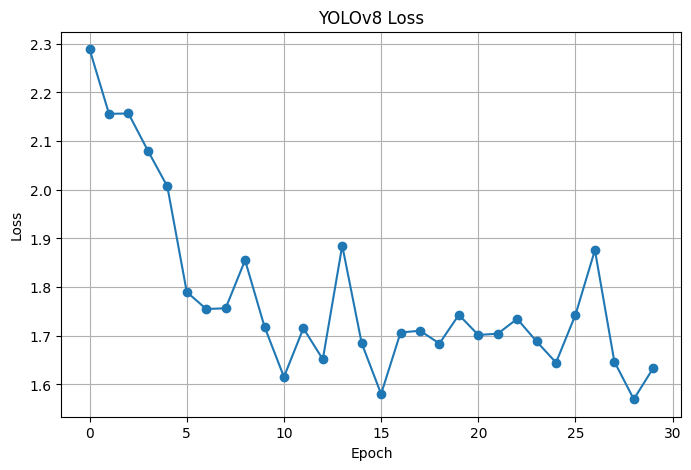

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###############################################################
# Dummy YOLOv8-style Detection Head
###############################################################

class YOLOv8Head(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,5)
        )

    def forward(self,x):
        return self.fc(x)

###############################################################
# Complete IoU (CIoU) Loss
###############################################################

def bbox_ciou_loss(pred_boxes, target_boxes):

    px1,py1,px2,py2 = pred_boxes[:,0],pred_boxes[:,1],pred_boxes[:,2],pred_boxes[:,3]
    tx1,ty1,tx2,ty2 = target_boxes[:,0],target_boxes[:,1],target_boxes[:,2],target_boxes[:,3]

    inter_x1=torch.max(px1,tx1)
    inter_y1=torch.max(py1,ty1)
    inter_x2=torch.min(px2,tx2)
    inter_y2=torch.min(py2,ty2)

    inter=(inter_x2-inter_x1).clamp(0)*(inter_y2-inter_y1).clamp(0)

    area_pred=(px2-px1).clamp(0)*(py2-py1).clamp(0)
    area_gt=(tx2-tx1).clamp(0)*(ty2-ty1).clamp(0)

    union=area_pred+area_gt-inter+1e-7

    iou=inter/union

    pred_cx=(px1+px2)/2
    pred_cy=(py1+py2)/2

    gt_cx=(tx1+tx2)/2
    gt_cy=(ty1+ty2)/2

    center_distance=(pred_cx-gt_cx)**2+(pred_cy-gt_cy)**2

    enclose_x1=torch.min(px1,tx1)
    enclose_y1=torch.min(py1,ty1)
    enclose_x2=torch.max(px2,tx2)
    enclose_y2=torch.max(py2,ty2)

    c2=((enclose_x2-enclose_x1)**2+
        (enclose_y2-enclose_y1)**2)+1e-7

    ciou=iou-center_distance/c2

    return (1-ciou).mean()

###############################################################
# Classification Loss
###############################################################

bce_loss = nn.BCEWithLogitsLoss()

###############################################################
# Dynamic Assignment
###############################################################

def dynamic_assignment(pred_boxes,gt_boxes):

    matched=[]

    for gt in gt_boxes:

        dist=((pred_boxes[:,:2]-gt[:2])**2).sum(1)

        idx=torch.argmin(dist)

        matched.append(idx)

    return torch.tensor(matched)

###############################################################
# Complete Loss
###############################################################

def yolo_loss(predictions,
              gt_boxes,
              gt_labels):

    pred_boxes=predictions[:,:4]

    pred_cls=predictions[:,4]

    matched=dynamic_assignment(pred_boxes.detach(),
                               gt_boxes)

    matched_boxes=pred_boxes[matched]

    matched_cls=pred_cls[matched]

    box_loss=bbox_ciou_loss(matched_boxes,
                            gt_boxes)

    cls_loss=bce_loss(matched_cls,
                      gt_labels.float())

    total_loss=box_loss+cls_loss

    return total_loss,box_loss,cls_loss

###############################################################
# Model
###############################################################

model=YOLOv8Head().to(device)

optimizer=optim.Adam(model.parameters(),
                     lr=0.001)

###############################################################
# Dummy Dataset
###############################################################

losses=[]

for epoch in range(30):

    features=torch.randn(20,256).to(device)

    gt_boxes=torch.rand(5,4).to(device)

    gt_boxes[:,2:]+=gt_boxes[:,:2]

    gt_labels=torch.randint(0,2,(5,)).float().to(device)

    predictions=model(features)

    loss,box_loss,cls_loss=yolo_loss(predictions,
                                     gt_boxes,
                                     gt_labels)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1}")

    print("Total Loss :",loss.item())

    print("CIoU Loss :",box_loss.item())

    print("Class Loss:",cls_loss.item())

###############################################################
# Plot
###############################################################

plt.figure(figsize=(8,5))

plt.plot(losses,marker='o')

plt.title("YOLOv8 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()